# Week4 预测 Pipeline

【里程碑 1】完整预测 Pipeline：数据处理、预测模式、参数选择、模型训练、评估可视化。

- **数据**：GEFCom2014 L1-train
- **预测模式**：Direct（多模型）、MIMO（MSVR）
- **参数选择**：PSO 超参数优化
- **评估**：RMSE / MAE，逐步长误差，可视化

## 1. 数据处理

In [37]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
from sko.PSO import PSO

# 路径兼容：从项目根目录或 week4 启动
_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week4' else _cwd
sys.path.insert(0, os.path.join(_root, 'week2'))
from data import GEFCom2014
from MSVR import MSVR

In [38]:
# 全局配置
D_NUM = 24   # 回看窗口（小时）
H_NUM = 24   # 预测步长（小时）
RANDOM_SEED = 42
CV_FOLDS = 5
PSO_PARTICLES = 20
PSO_ITER = 25

In [39]:
# 加载并预处理数据
np.random.seed(RANDOM_SEED)
gefcom2014 = GEFCom2014(test_ratio=0.33)

# 滑窗构造训练/测试集
X_tr_3d, y_train = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=H_NUM, is_train=True)
X_te_3d, y_test = gefcom2014.get_slided_dataset(d_num=D_NUM, h_num=H_NUM, is_train=False)

X_train = X_tr_3d.reshape(len(X_tr_3d), -1)
X_test = X_te_3d.reshape(len(X_te_3d), -1)

print(f'训练集: X {X_train.shape}, y {y_train.shape}')
print(f'测试集: X {X_test.shape}, y {y_test.shape}')

训练集: X (622, 24), y (622, 24)
测试集: X (284, 24), y (284, 24)


## 2. 参数选择（PSO）

Direct 与 MIMO 分别独立优化超参数 C、γ、ε。

In [40]:
SEARCH_SPACE = {
    'C': np.exp(np.linspace(np.log(1), np.log(100), 16)),
    'gamma': np.array([0.05, 0.1, 0.2, 0.4]),
    'epsilon': np.logspace(-4, -2, 4),
}

LOWER_BOUNDS = np.zeros(3, dtype=float)
UPPER_BOUNDS = np.array([len(SEARCH_SPACE['C'])-1, len(SEARCH_SPACE['gamma'])-1, len(SEARCH_SPACE['epsilon'])-1], dtype=float)

cv_splitter = TimeSeriesSplit(n_splits=CV_FOLDS)
fitness_cache_direct = {}
fitness_cache_mimo = {}

def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(rmse_score, greater_is_better=False)

def decode_particle(position):
    idx = np.clip(np.rint(np.asarray(position)).astype(int), LOWER_BOUNDS.astype(int), UPPER_BOUNDS.astype(int))
    params = {
        'C': float(SEARCH_SPACE['C'][idx[0]]),
        'gamma': float(SEARCH_SPACE['gamma'][idx[1]]),
        'epsilon': float(SEARCH_SPACE['epsilon'][idx[2]]),
    }
    return idx, params

def fitness_direct_cv(position, stats):
    idx, params = decode_particle(position)
    cache_key = tuple(idx.tolist())
    stats['n_evaluations'] += 1
    if cache_key not in fitness_cache_direct:
        model = SVR(kernel='rbf', C=params['C'], gamma=params['gamma'], epsilon=params['epsilon'])
        scores = cross_val_score(model, X_train, y_train[:, 0], cv=cv_splitter, scoring=rmse_scorer, n_jobs=1)
        fitness_cache_direct[cache_key] = -float(np.mean(scores))
    return fitness_cache_direct[cache_key]

def fitness_mimo_cv(position, stats):
    idx, params = decode_particle(position)
    cache_key = tuple(idx.tolist())
    stats['n_evaluations'] += 1
    if cache_key not in fitness_cache_mimo:
        scores = []
        for train_idx, val_idx in cv_splitter.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]
            m = MSVR(kernel='rbf', C=params['C'], gamma=params['gamma'], epsilon=params['epsilon'])
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_val)
            scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        fitness_cache_mimo[cache_key] = np.mean(scores)
    return fitness_cache_mimo[cache_key]

def run_pso_direct():
    np.random.seed(RANDOM_SEED)
    fitness_cache_direct.clear()
    stats = {'n_evaluations': 0}
    pso = PSO(func=lambda x: fitness_direct_cv(x, stats), n_dim=3, pop=PSO_PARTICLES, max_iter=PSO_ITER,
              lb=LOWER_BOUNDS, ub=UPPER_BOUNDS, w=0.7, c1=1.5, c2=1.5)
    pso.run()
    best_idx, best_params = decode_particle(np.asarray(pso.gbest_x, dtype=float))
    return best_params, np.asarray(pso.gbest_y_hist, dtype=float).reshape(-1)

def run_pso_mimo():
    np.random.seed(RANDOM_SEED + 1)
    fitness_cache_mimo.clear()
    stats = {'n_evaluations': 0}
    pso = PSO(func=lambda x: fitness_mimo_cv(x, stats), n_dim=3, pop=PSO_PARTICLES, max_iter=PSO_ITER,
              lb=LOWER_BOUNDS, ub=UPPER_BOUNDS, w=0.7, c1=1.5, c2=1.5)
    pso.run()
    best_idx, best_params = decode_particle(np.asarray(pso.gbest_x, dtype=float))
    return best_params, np.asarray(pso.gbest_y_hist, dtype=float).reshape(-1)

In [41]:
# Direct 独立优化
best_params_direct, gbest_hist_direct = run_pso_direct()
print('Direct PSO 最优超参数:', best_params_direct)

# MIMO 独立优化
best_params_mimo, gbest_hist_mimo = run_pso_mimo()
print('MIMO PSO 最优超参数:', best_params_mimo)

Direct PSO 最优超参数: {'C': 100.00000000000004, 'gamma': 0.05, 'epsilon': 0.0001}
MIMO PSO 最优超参数: {'C': 54.11695265464639, 'gamma': 0.05, 'epsilon': 0.0001}


## 3. 预测模式与模型训练

- **Direct**：每个步长独立训练一个 SVR
- **MIMO**：单 MSVR 多输出

In [42]:
results = {}

# Direct 策略（使用 Direct 优化参数）
svr_direct_models = []
y_pred_direct = np.zeros((len(X_test), H_NUM))
for h_idx in range(H_NUM):
    model = SVR(kernel='rbf', C=best_params_direct['C'], gamma=best_params_direct['gamma'], epsilon=best_params_direct['epsilon'])
    model.fit(X_train, y_train[:, h_idx])
    svr_direct_models.append(model)
    y_pred_direct[:, h_idx] = model.predict(X_test)
    if (h_idx + 1) % 6 == 0:
        print(f'  Direct 步长 {h_idx+1}/{H_NUM} 完成')
results['Direct'] = y_pred_direct

# MIMO 策略（使用 MIMO 优化参数）
mimo_model = MSVR(kernel='rbf', C=best_params_mimo['C'], epsilon=best_params_mimo['epsilon'], gamma=best_params_mimo['gamma'])
mimo_model.fit(X_train, y_train)
y_pred_mimo = mimo_model.predict(X_test)
results['MIMO'] = y_pred_mimo
print('MIMO 训练完成')

  Direct 步长 6/24 完成
  Direct 步长 12/24 完成
  Direct 步长 18/24 完成
  Direct 步长 24/24 完成
MIMO 训练完成


## 4. 评估

In [43]:
def evaluate(y_true, y_pred, name=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'[{name}] RMSE: {rmse:.4f} | MAE: {mae:.4f}')
    return rmse, mae

for name, y_pred in results.items():
    evaluate(y_test, y_pred, name)

[Direct] RMSE: 0.1206 | MAE: 0.0901
[MIMO] RMSE: 0.1140 | MAE: 0.0868


In [44]:
# 汇总指标并保存
rows = []
for name, y_pred in results.items():
    rows.append({'strategy': name, 'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
                 'mae': mean_absolute_error(y_test, y_pred)})
metrics_df = pd.DataFrame(rows)
metrics_df

,strategy,rmse,mae
0,Direct,0.120632,0.090122
1,MIMO,0.113960,0.086821


In [45]:
# 逐步长 RMSE/MAE 并保存
horizon_rows = []
for name, y_pred in results.items():
    for h in range(H_NUM):
        horizon_rows.append({
            'strategy': name, 'horizon': h+1,
            'rmse': np.sqrt(mean_squared_error(y_test[:, h], y_pred[:, h])),
            'mae': mean_absolute_error(y_test[:, h], y_pred[:, h])
        })
horizon_df = pd.DataFrame(horizon_rows)

## 5. 可视化

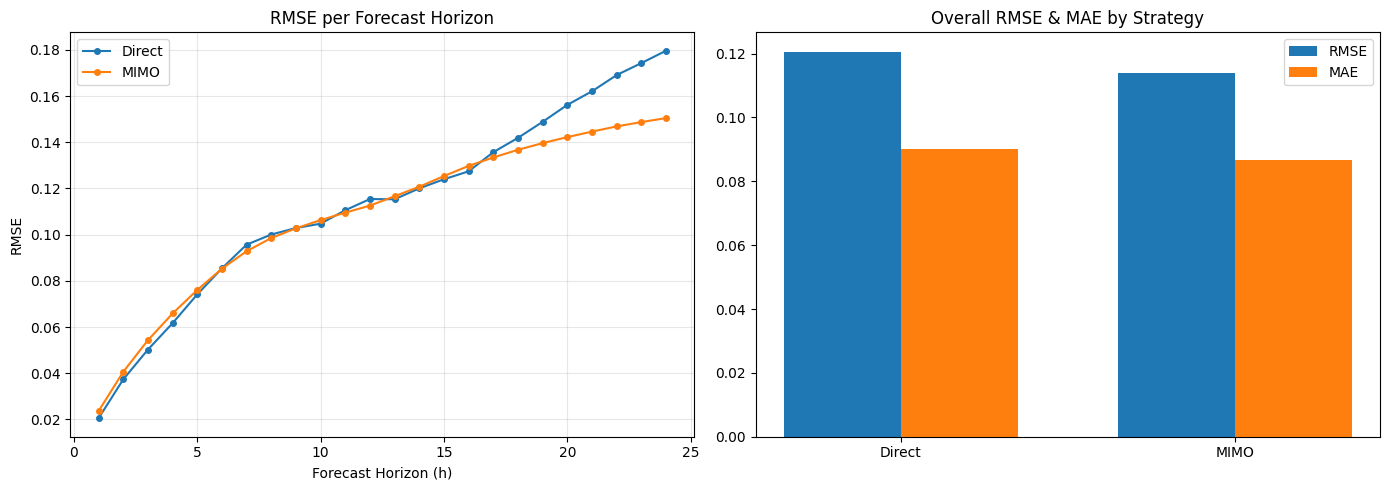

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：逐步长 RMSE
ax = axes[0]
for name, y_pred in results.items():
    rmse_per_h = [np.sqrt(mean_squared_error(y_test[:, h], y_pred[:, h])) for h in range(H_NUM)]
    ax.plot(range(1, H_NUM+1), rmse_per_h, marker='o', markersize=4, label=name)
ax.set_xlabel('Forecast Horizon (h)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE per Forecast Horizon')
ax.legend()
ax.grid(True, alpha=0.3)

# 右图：总体 RMSE / MAE 柱状图
ax2 = axes[1]
names = list(results.keys())
rmses = [np.sqrt(mean_squared_error(y_test, results[n])) for n in names]
maes = [mean_absolute_error(y_test, results[n]) for n in names]
x = np.arange(len(names))
width = 0.35
ax2.bar(x - width/2, rmses, width, label='RMSE')
ax2.bar(x + width/2, maes, width, label='MAE')
ax2.set_xticks(x)
ax2.set_xticklabels(names)
ax2.set_title('Overall RMSE & MAE by Strategy')
ax2.legend()
plt.tight_layout()
plt.show()

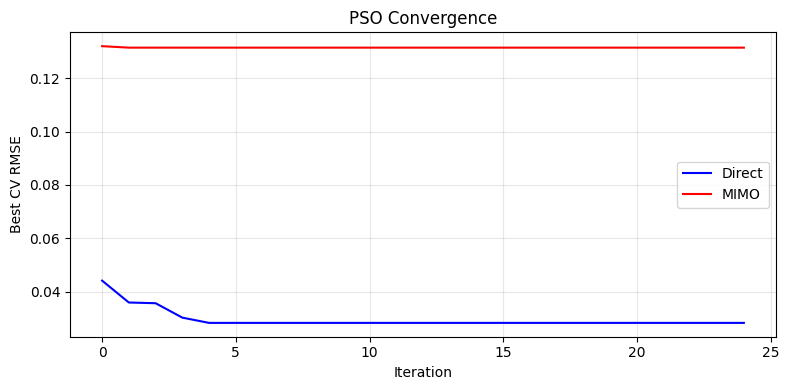

In [47]:
# PSO 收敛曲线（Direct 与 MIMO 分开优化）
plt.figure(figsize=(8, 4))
plt.plot(gbest_hist_direct, 'b-', label='Direct')
plt.plot(gbest_hist_mimo, 'r-', label='MIMO')
plt.xlabel('Iteration')
plt.ylabel('Best CV RMSE')
plt.title('PSO Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

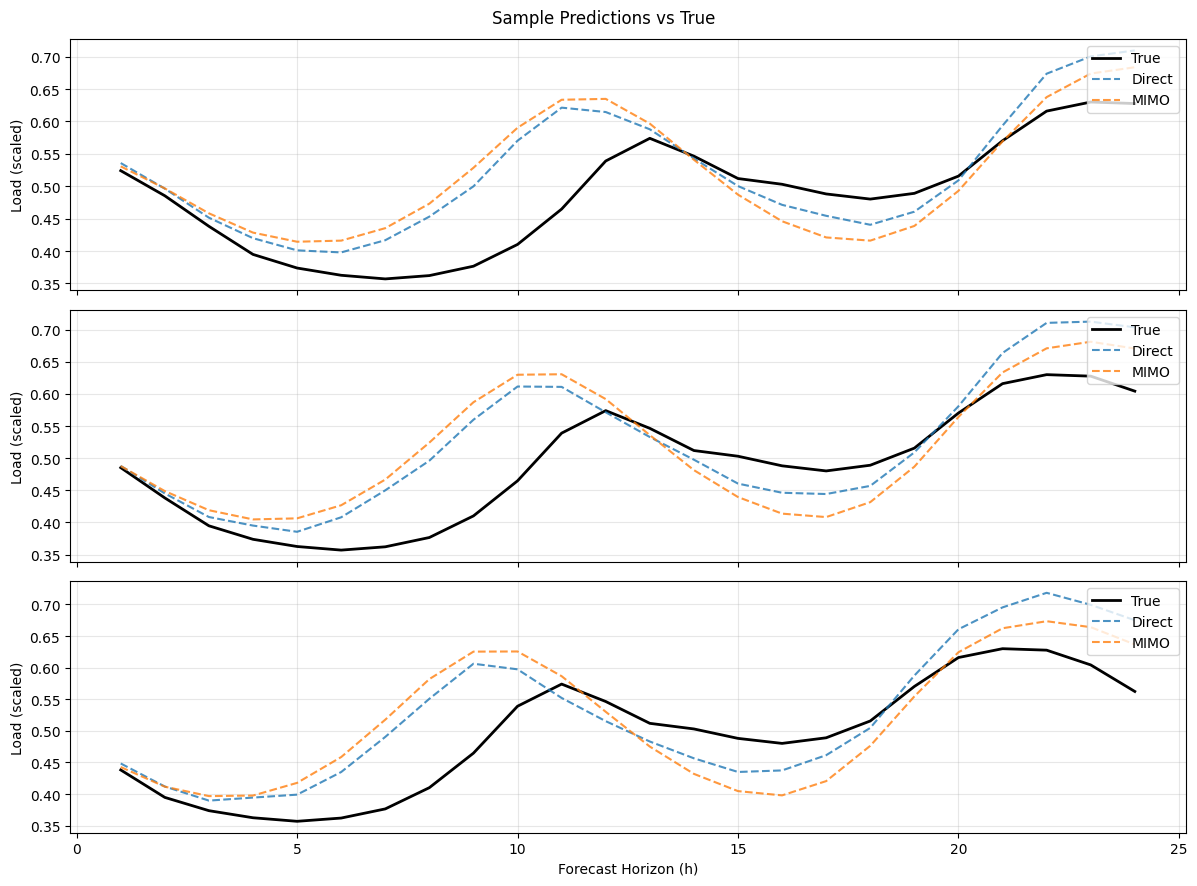

In [48]:
# 预测 vs 真实（选取若干样本）
n_show = min(3, len(X_test))
fig, axes = plt.subplots(n_show, 1, figsize=(12, 3*n_show), sharex=True)
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(range(1, H_NUM+1), y_test[i], 'k-', label='True', linewidth=2)
    for name, y_pred in results.items():
        ax.plot(range(1, H_NUM+1), y_pred[i], '--', label=name, alpha=0.8)
    ax.set_ylabel('Load (scaled)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Forecast Horizon (h)')
plt.suptitle('Sample Predictions vs True')
plt.tight_layout()
plt.show()